# End-to-End Bayesian Optimization Demo

This notebook demonstrates the complete workflow of the multi-objective Bayesian optimization system for heat treatment parameters.

## Overview
- Load and explore experimental data
- Run Bayesian optimization
- Analyze results and Pareto front
- Generate comprehensive plots and metrics

## 1. System Imports

In [12]:
# Import necessary libraries
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from notebook_filemanager import setup_notebook_environment, get_notebook_file_manager, calculate_hypervolume_progress


# Setup notebook environment and get patched modules
bo, plotting = setup_notebook_environment()

## 2. Load Configuration and Data

In [13]:
# Initialize file manager
fm = get_notebook_file_manager()
print("Notebook Configuration is loaded!")
print(f"Bounds: {fm.get_bounds()}")
print(f"Reference point: {fm.get_reference_point()}")
print(f"Using data file: {fm.get_paths()['database_demo']}")

Notebook Configuration is loaded!
Bounds: [[ 950   15  600  120]
 [1200  120  860  480]]
Reference point: [200   0]
Using data file: mobo_data.csv


## 3. Load Experimental Data

In [14]:
# Load data from CSV
data = pd.read_csv('mobo_data.csv')
print(f"Loaded {len(data)} experiments")
print("\nData preview:")
data.head()

Loaded 20 experiments

Data preview:


,T1 (C),t1 (min),T2 (C),t2 (min),Ultimate Tensile Strength (MPa),Energy (kWh)
0,1162,99.2,814,303.45,1125.33,5.13
1,1035,94.8,635,442.16,1120.67,3.47
2,1101,72.4,677,198.57,1221.00,3.15
3,1081,40.9,790,357.36,1316.00,3.46
4,964,27.3,707,132.44,1386.67,1.83


## 4. Summary Statistics

In [15]:
# Summary of key metrics
print("=" * 50)
print("EXPERIMENTAL SUMMARY")
print("=" * 50)
print(f"Total experiments: {len(data)}")
print(f"UTS range: {data['Ultimate Tensile Strength (MPa)'].min():.1f} - {data['Ultimate Tensile Strength (MPa)'].max():.1f} MPa")
print(f"Energy range: {data['Energy (kWh)'].min():.2f} - {data['Energy (kWh)'].max():.2f} kWh")
print(f"Best UTS: {data['Ultimate Tensile Strength (MPa)'].max():.1f} MPa")
print(f"Lowest Energy: {data['Energy (kWh)'].min():.2f} kWh")

EXPERIMENTAL SUMMARY
Total experiments: 20
UTS range: 798.3 - 1492.7 MPa
Energy range: 1.40 - 5.13 kWh
Best UTS: 1492.7 MPa
Lowest Energy: 1.40 kWh


## 5. Advanced Analysis with Bayesian Optimization Tools

In [16]:
# Use the BO system to identify Pareto front from our data
train_x = data[['T1 (C)', 't1 (min)', 'T2 (C)', 't2 (min)']].values
train_y_original = data[['Ultimate Tensile Strength (MPa)', 'Energy (kWh)']].values

# Transform energy (1/energy for maximization)
train_y_transformed = np.copy(train_y_original)
train_y_transformed[:, 1] = 1.0 / train_y_original[:, 1]

# Identify Pareto front using BO functions
pareto_x, pareto_y, pareto_y_original = bo.identify_pareto_front(
    train_x, train_y_transformed, train_y_original
)

print(f"\nPareto Analysis Results:")
print(f"Total experiments: {len(train_x)}")
print(f"Pareto-optimal points: {len(pareto_x)}")

print(f"\nPareto-Optimal Experiments:")
for i, (params, results) in enumerate(zip(pareto_x, pareto_y_original)):
    print(f"P{i+1}: T1={params[0]:.0f}°C, t1={params[1]:.1f}min, T2={params[2]:.0f}°C, t2={params[3]:.1f}min")
    print(f"     UTS={results[0]:.1f}MPa, Energy={results[1]:.3f}kWh")


Pareto Analysis Results:
Total experiments: 20
Pareto-optimal points: 5

Pareto-Optimal Experiments:
P1: T1=950°C, t1=15.0min, T2=753°C, t2=280.0min
     UTS=1451.0MPa, Energy=2.400kWh
P2: T1=950°C, t1=15.0min, T2=600°C, t2=120.0min
     UTS=1044.7MPa, Energy=1.400kWh
P3: T1=950°C, t1=15.0min, T2=760°C, t2=120.0min
     UTS=1411.7MPa, Energy=1.730kWh
P4: T1=985°C, t1=15.0min, T2=740°C, t2=294.0min
     UTS=1492.7MPa, Energy=2.470kWh
P5: T1=1034°C, t1=15.0min, T2=740°C, t2=227.0min
     UTS=1441.3MPa, Energy=2.280kWh


In [17]:
# Calculate hypervolume for the current dataset
hypervolume = bo.calculate_hypervolume(pareto_y)
print(f"\nHypervolume: {hypervolume:.4f}")


Hypervolume: 849.3828


## 6. Visualization of Pareto Front

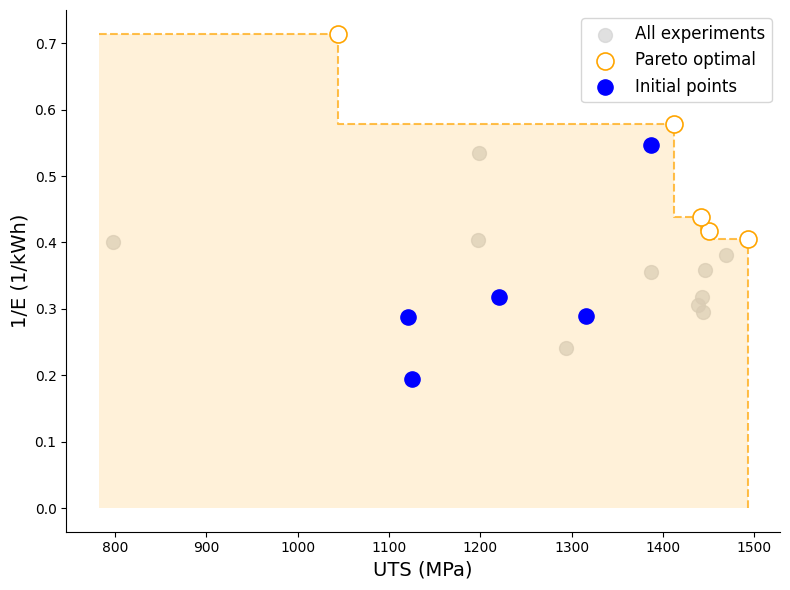


=== PARETO-OPTIMAL EXPERIMENT PARAMETERS ===
ID  T1(C)  t1(min)  T2(C)  t2(min)  UTS(MPa)  Energy(kWh)
------------------------------------------------------------
P1  950   15.0    753   280.0    1451.0      2.40
P2  950   15.0    600   120.0    1044.7      1.40
P3  950   15.0    760   120.0    1411.7      1.73
P4  985   15.0    740   294.0    1492.7      2.47
P5  1034   15.0    740   227.0    1441.3      2.28


In [18]:
bo.plot_pareto_front(train_x, train_y_transformed, train_y_original, 
                     pareto_x, pareto_y, pareto_y_original, iteration=1)

## 7. Advanced Analysis Using Plotting Module Functions

LOOCV PARITY PLOTS - MODEL VALIDATION
Purpose: Validate GP surrogate models used in Bayesian optimization
Method: Leave-one-out cross-validation
Shows: Prediction accuracy and uncertainty calibration


Generating Uts LOOCV Plot...


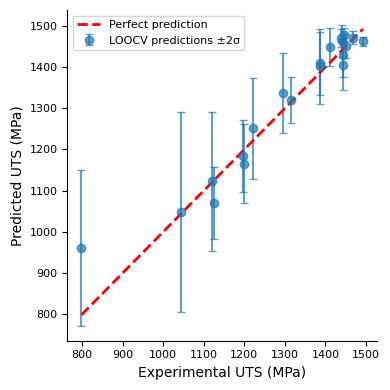

Saved: ./loocv_UTS_validation.png

Generating Energy LOOCV Plot...


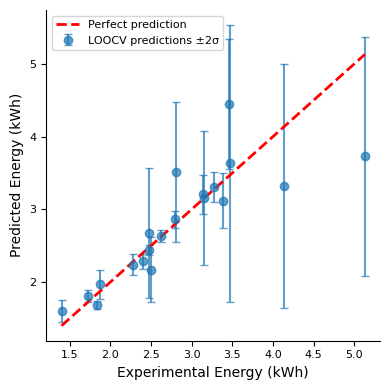

Saved: ./loocv_energy_validation.png

INTERPRETATION:
- Points close to red line = accurate predictions
- Small error bars = confident predictions
- Large error bars = uncertain predictions
- This validates that GP models can predict properties from heat treatment parameters

Generated files:
- loocv_UTS_validation.png
- loocv_energy_validation.png
LOOCV validation plots generated


In [19]:
# Generate LOOCV validation plots
train_x, train_y_transformed, train_y_original = plotting.load_data_from_database()
plotting.loocv_validation_detailed(train_x, train_y_transformed, train_y_original, bo.BOUNDS)
print("LOOCV validation plots generated")


UNCERTAINTY HEATMAPS
Purpose: Show where GP models are confident vs uncertain for each property
Method: 2D slices through 4D parameter space
Shows: Dark purple = confident, Bright yellow = uncertain



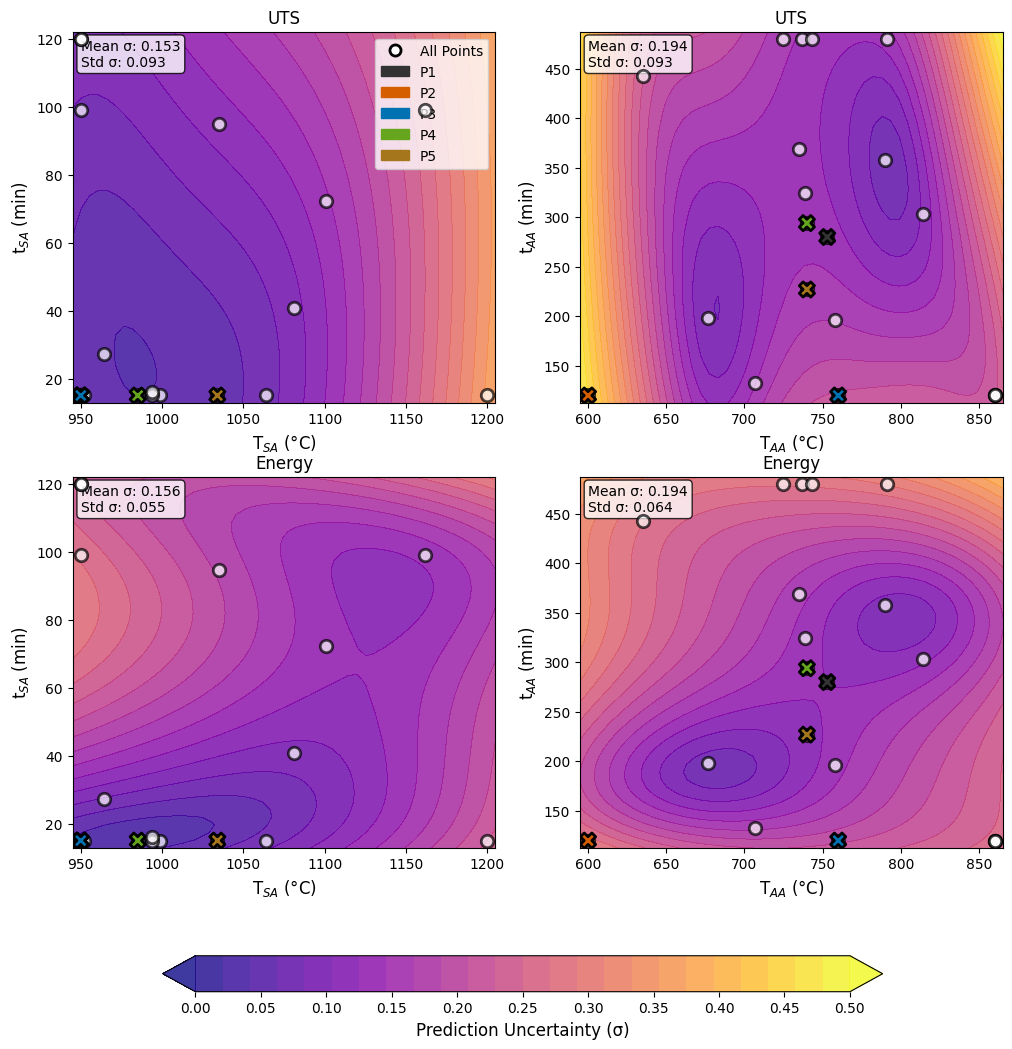


INTERPRETATION:
- Dark purple regions = model is confident (low uncertainty)
- Bright yellow regions = model is uncertain (needs more experiments)

Generated files:
- uncertainty_heatmaps.png
Uncertainty heatmaps generated


In [20]:
# Generate uncertainty heatmaps
c_blind_colors = ["#333333", "#D55E00", "#0072B2", "#66A61E", "#A6761D", "#E7298A"]
plotting.uncertainty_heatmaps(train_x, train_y_transformed, train_y_original, bo.BOUNDS, c_blind_colors)
print("Uncertainty heatmaps generated")

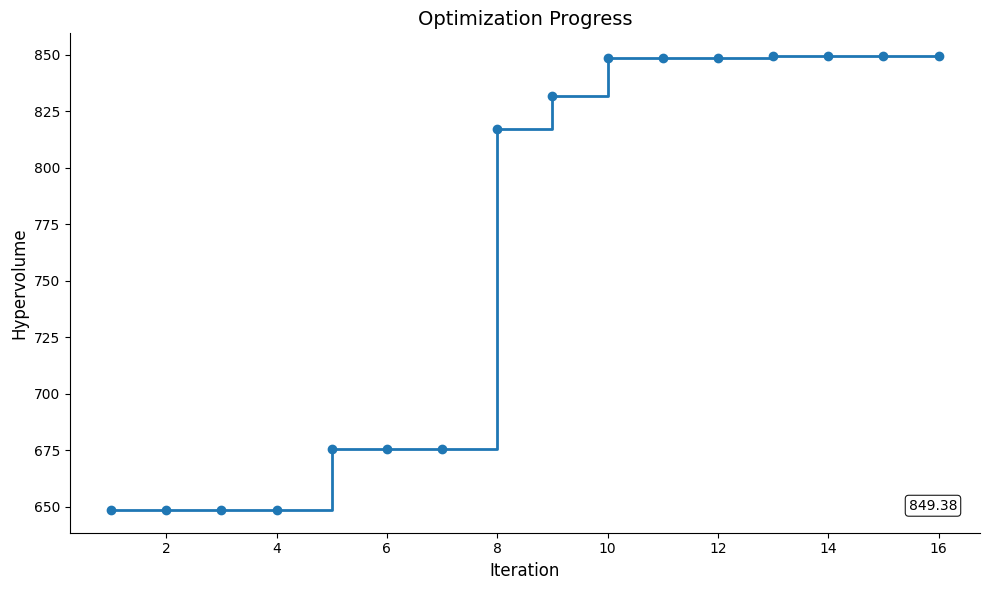

Hypervolume progress plot generated


In [21]:
# Generate hypervolume progress plot
iterations, hypervolumes = calculate_hypervolume_progress(bo, train_x, train_y_transformed, train_y_original, fm.config)
bo.plot_hypervolume_progress(iterations, hypervolumes)
print("Hypervolume progress plot generated")

## 10. Summary

In [22]:
print("\n" + "="*60)
print("DEMO COMPLETED SUCCESSFULLY!")
print("="*60)
print("\nThis demo showed:")
print("- Data loading and analysis from mobo_data.csv")
print("- Pareto front identification using BO algorithms")
print("- Hypervolume calculation for optimization quality")
print("- Advanced plotting and analysis functions")
print("\nAll analysis used the same logic as bo.py and plotting.py")


DEMO COMPLETED SUCCESSFULLY!

This demo showed:
- Data loading and analysis from mobo_data.csv
- Pareto front identification using BO algorithms
- Hypervolume calculation for optimization quality
- Advanced plotting and analysis functions

All analysis used the same logic as bo.py and plotting.py
